In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, scipy

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)
# tf.config.run_functions_eagerly(True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm
from icecream import ic

from msfm.grid_pipeline import GridPipeline
from msfm.utils import logger, files, scales, power_spectra, parameters

from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization, configuration
from deep_lss.nets.mlp import MultiLayerPerceptron

from msi.utils import preprocessing, dataset, input_output

### v11

In [3]:
# msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v11/extended.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v11/extended"
# mocks = ["Buzzard", "Cardinal"]

# # dlss_conf = configuration.load_deep_lss_config(
# #     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_28mpc.yaml"
# # )


# label = "16mpc"
# # label = "20mpc"
# # label = "24mpc"
# # label = "28mpc"
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_{label}.yaml"
# )
# # label += "_octant"

# out_dir = "/pscratch/sd/a/athomsen/run_files/v11"
# # out_dir += "/octant"

In [4]:
# with_lensing = True
# with_clustering = False
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# mocks = []

In [5]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

In [6]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

### v12

In [7]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v12/nonlinear.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v12/nonlinear"
mocks = ["Buzzard", "Cardinal"]

# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_28mpc.yaml"
# )

label = "16mpc"
# label = "20mpc"
# label = "24mpc"
# label = "28mpc"
dlss_conf = configuration.load_deep_lss_config(
    f"/global/u2/a/athomsen/y3-deep-lss/configs/v12/clustering/smoothing_fwhm/dlss_{label}.yaml"
)
# label += "_octant"
# label += "_no_cross_z"

out_dir = "/pscratch/sd/a/athomsen/run_files/v12"
# out_dir += "/octant"

24-12-13 11:34:04 configuratio INF   Loaded the config 


In [8]:
# with_lensing = True
# with_clustering = False
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# mocks = []

In [9]:
with_lensing = False
with_clustering = True
with_cross_z = True
params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4", "qbg1", "qbg2", "qbg3", "qbg4"]

In [10]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

# constants

In [11]:
batch_size = 2**12
# batch_size = 2**10
shuffle_buffer = 4*batch_size
apply_log = True
standardize = False

out_dir = os.path.join(out_dir, "cls/cca", f"lensing={with_lensing},clustering={with_clustering},log={apply_log},standard={standardize}")
if label is not None:
    out_dir = os.path.join(out_dir, label)
os.makedirs(out_dir, exist_ok=True)

# white noise dset

24-12-13 11:34:24 configuratio INF   Loaded the config 
24-12-13 11:34:24 preprocessin INF   Using theta_fwhm = [22.1, 15.1, 11.2, 9.4, 65.1, 44.5, 34.1, 28.5] from the dlss config 
24-12-13 11:34:24 preprocessin INF   Using white_noise_sigma = [0.0010012, 0.0013444, 0.0016358, 0.0017096, 0.52009, 0.20641, 0.14949, 0.13531] from the dlss config 
24-12-13 11:34:24 preprocessin INF   Using l_maxs = [ 488.68778281  715.23178808  964.28571429 1148.93617021  165.89861751
  242.69662921  316.71554252  378.94736842] from the dlss config 
24-12-13 11:34:24 preprocessin INF   Using l_mins = [0. 0. 0. 0. 0. 0. 0. 0.] by default (no smoothing) 
24-12-13 11:34:24 preprocessin INF   Using n_bins = 33 from the msfm config 
24-12-13 11:34:24 preprocessin INF   Loading the pre-binned Cls 
24-12-13 11:34:24 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/v12/nonlinear 
24-12-13 11:34:24 input_output INF   Array shapes: 
24-12-13 11:34:24 input_output INF   fiducial/i_example 

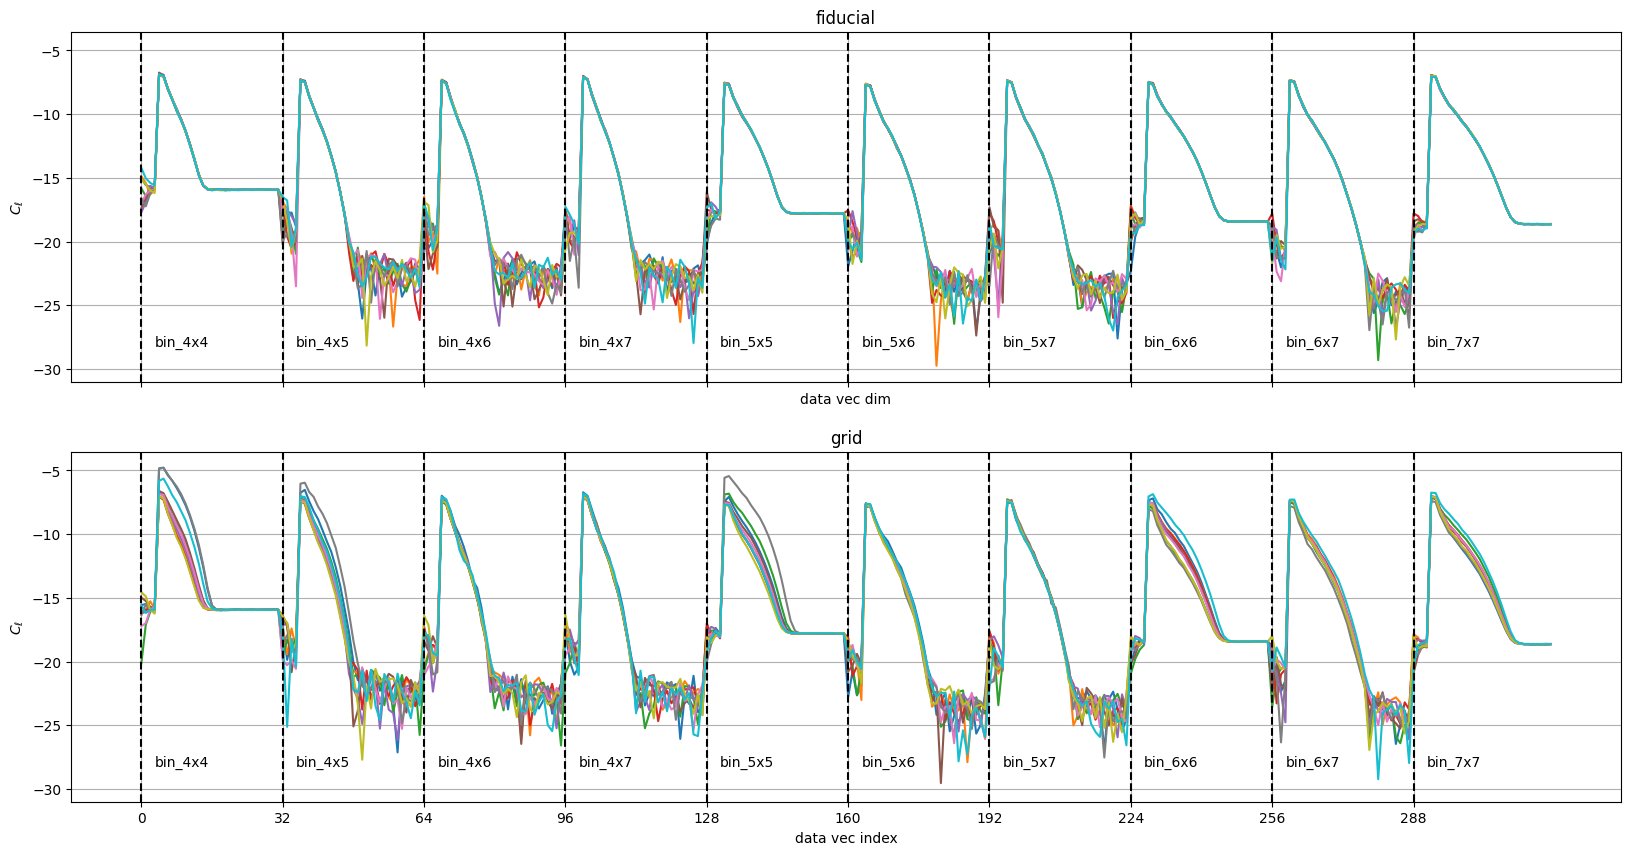

In [12]:
cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_gaussian_noise=True,
    # bin_indices=[bin_index],
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # smoothing not from the dlss_conf
    # theta_fwhms=theta_fwhm,
    # white_noise_sigmas=white_noise_sigma,
    # cls_from_maps=True,
    # preprocessing
    apply_log=apply_log,
    standardize=standardize,
)

# hard cut dset

In [13]:
# l_mins = 8 * [30]
# l_maxs = [786, 1150, 1535, 1535, 267, 390, 509, 610]

# # def angle_to_ell(angles):
# #     return list(scales.angle_to_ell(np.array(angles), arcmin=True))
# # l_maxs = angle_to_ell([22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5])

# cl_dset_train, cl_dset_test, out_dict, scaler, pca = dataset.get_binned_power_spectra_dset_legacy(
#     base_dir, 
#     # configuration
#     msfm_conf=msfm_conf, 
#     dlss_conf=dlss_conf,
#     params=params,
#     # selection
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     # dset
#     batch_size=batch_size,
#     shuffle_buffer=shuffle_buffer,
#     # power spectra
#     l_mins=l_mins,
#     l_maxs=l_maxs,
#     # n_bins=n_bins,
#     fixed_binning=False,
#     # additional preprocessing
#     apply_log=apply_log,
#     standardize=standardize,
# )

In [14]:
# fig, ax = plt.subplots()

# steps = 3
# for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(steps)), total=steps):
#     ax.plot(cl_batch[0])

# ax.set(xlabel=r"$\ell$", ylabel=r"$C_\ell$")

# fixed compression
Following https://github.com/98minsu/CosmoCompression/blob/main/notebook.ipynb
and
```
n_params = 16
cov = np.cov(params_3[mask].T, DV3[mask].T)
cp = cov[:n_params,:n_params]
cd = cov[n_params:,n_params:]
cpd = cov[:n_params,n_params:]

# This 'cl' can be understood as the projection of 'cp' to data vector space
cl = cpd.T@np.linalg.inv(cp)@cpd

# As seen in the paper, this generalized eigenvalue problem is equivalent to CCA
# but is more numerical stable as 'cd' and 'cd-cl' are both invertible.
# This problem is motivated as mutual information maximization under Gaussian linear model assumptions
evals, evecs = linalg.eigh(cd, cd - cl)

# In the context of the CCA, only min( dim(param), dim(data vector) ) components are real and the rest are noise.
evals = evals[::-1][:n_params]
evecs = evecs[:,::-1][:,:n_params]

# compresssion
compressed_dv = DV3@evecs
```

In [15]:
grid_cls = out_dict["grid/cls/train"]
grid_cosmos = out_dict["grid/cosmos/train"]

print("grid_cls.shape", grid_cls.shape)
print("grid_cosmos.shape", grid_cosmos.shape)

n_params = grid_cosmos.shape[-1]

# Compute the sampled parameter auto covariance, simulated data vector auto covariance
# and the parameter-data vector cross covariance
cov = np.cov(grid_cosmos, grid_cls, rowvar=False)
cp = cov[:n_params,:n_params]
cd = cov[n_params:,n_params:]
cpd = cov[:n_params,n_params:]

# This 'cl' can be understood as the projection of 'cp' to data vector space
cl = cpd.T @ np.linalg.inv(cp) @ cpd

# As seen in the paper, this generalized eigenvalue problem is equivalent to CCA
# but is more numerical stable as 'cd' and 'cd-cl' are both invertible.
# This problem is motivated as mutual information maximization under Gaussian linear model assumptions
evals, evecs = scipy.linalg.eigh(cd, cd - cl)

# In the context of the CCA, only min( dim(param), dim(data vector) ) components are real and the rest are noise. 
evals = evals[::-1][:n_params]
evecs = evecs[:,::-1][:,:n_params]

# # compression
# grid_dv = grid_cls @ evecs
# print("grid_dv.shape", grid_dv.shape)

grid_cls.shape (800000, 320)
grid_cosmos.shape (800000, 11)


In [16]:
out_dict.keys()

dict_keys(['fidu/cls', 'grid/cls/train', 'grid/cls/test', 'grid/cosmos/train', 'grid/cosmos/test'])

# save the results

In [17]:
fidu_preds = out_dict["fidu/cls"] @ evecs
grid_preds = out_dict["grid/cls/test"] @ evecs


In [16]:
fidu_preds = out_dict["fidu/cls"] @ evecs
grid_preds = out_dict["grid/cls/test"] @ evecs

pred_file = os.path.join(out_dir, "preds.h5")
with h5py.File(pred_file, "w") as f:
    f.create_dataset(name="grid/preds/test", data=grid_preds)
    f.create_dataset(name="grid/cosmos/test", data=out_dict["grid/cosmos/test"])
    f.create_dataset(name="fidu/preds", data=fidu_preds)

print(f"Wrote to {pred_file}\n")
print(fidu_preds)

Wrote to /pscratch/sd/a/athomsen/run_files/v12/cls/cca/lensing=False,clustering=True,log=True,standard=False/16mpc/preds.h5

[[ 41.27864648   8.56073306  -5.85876469 ... -23.74591972 -61.33988676
   27.51604647]
 [ 41.30471391   8.7046954   -5.92202523 ... -23.76476984 -61.2941767
   26.96027115]
 [ 41.65136065   8.55081203  -6.16864847 ... -24.14672853 -60.5622277
   27.34451756]
 ...
 [ 40.98136375   7.76524562  -6.46911414 ... -24.81714395 -61.37824768
   27.20045983]
 [ 41.18597717   7.88876817  -6.26261614 ... -24.68464254 -61.12911269
   27.46599259]
 [ 41.1096454    7.32361631  -6.21011594 ... -24.88521361 -61.2068009
   26.96445069]]


### external mocks

24-10-25 08:05:00     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 08:05:00 configuratio INF   Loaded the config 
24-10-25 08:05:00 preprocessin INF   Using l_maxs = [ 488.68778281  715.23178808  964.28571429 1148.93617021  165.89861751
  242.69662921  316.71554252  378.94736842] from the dlss config 
24-10-25 08:05:00 preprocessin INF   Using l_mins = [0 0 0 0 0 0 0 0] by default (no smoothing) 
24-10-25 08:05:00     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 08:05:00     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 08:05:18 preprocessin INF   Adding white noise to the observation 
24-10-25 08:05:18 preprocessin INF   Using the bin indices [26, 27, 28, 29, 30, 31, 32, 33, 34, 35] 
24-10-25 08:0

NameError: name 'model' is not defined

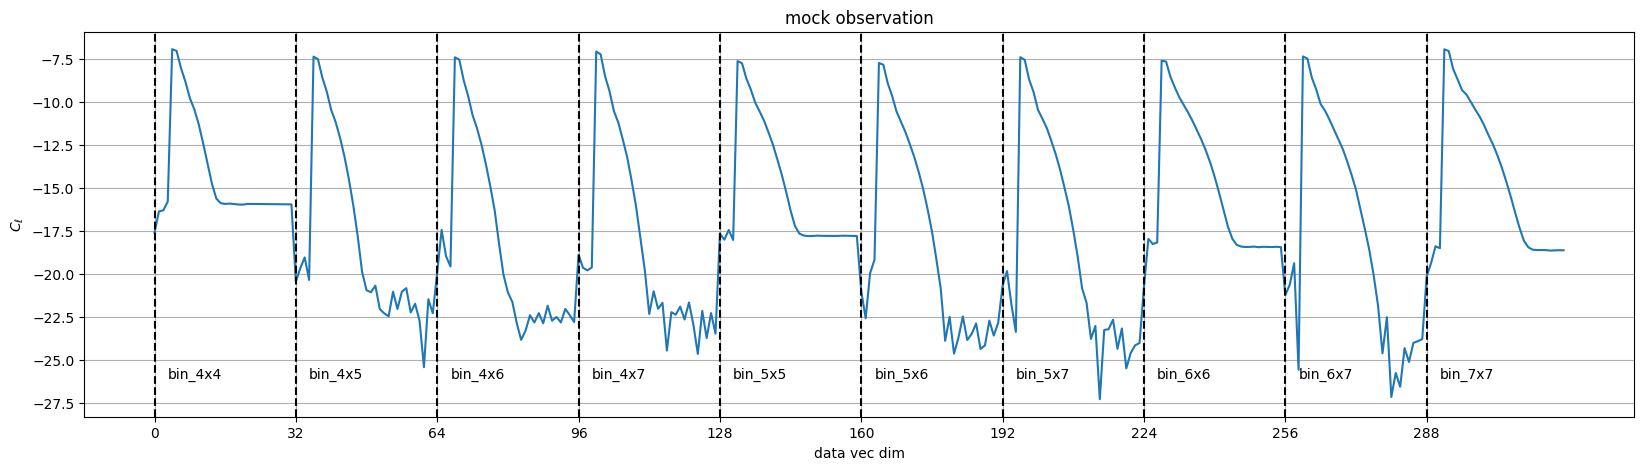

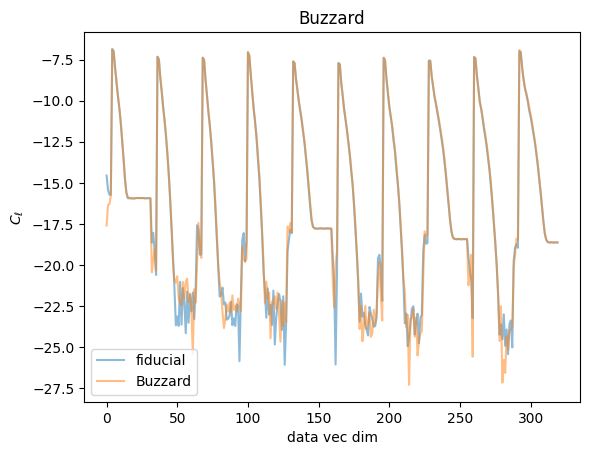

In [69]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# with h5py.File(pred_file, "a") as f_out:
#     for obs_label in mocks:
#         obs_file = f"/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_mock_observation_{obs_label}.h5"

#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             msfm_conf=msfm_conf,
#             dlss_conf=dlss_conf,
#             base_dir=base_dir,
#             from_raw_cls=False,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=with_cross_z,
#             with_cross_probe=(with_lensing and with_clustering),
#             # bin_indices=[bin_index],
#             # additional preprocessing
#             apply_log=apply_log,
#             # standardize=standardize,
#             # scaler=scaler,
#             # pca_components=None,
#             # pca=pca,
#         )
        
#         fig, ax = plt.subplots()
#         ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
#         ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=0.5)
#         ax.legend(loc="best")
#         ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$", title=obs_label)

#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)


### Buzzard flock

24-10-25 05:16:36     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 05:16:36 configuratio INF   Loaded the config 
24-10-25 05:16:36 preprocessin INF   Using l_maxs = [ 488.68778281  715.23178808  964.28571429 1148.93617021  165.89861751
  242.69662921  316.71554252  378.94736842] from the dlss config 
24-10-25 05:16:36 preprocessin INF   Using l_mins = [0 0 0 0 0 0 0 0] by default (no smoothing) 
24-10-25 05:16:36     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 05:16:36     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 05:16:53 preprocessin INF   Adding white noise to the observation 
24-10-25 05:16:53 preprocessin INF   Using the bin indices [26, 30, 33, 35] 
24-10-25 05:16:53 preprocessin INF   

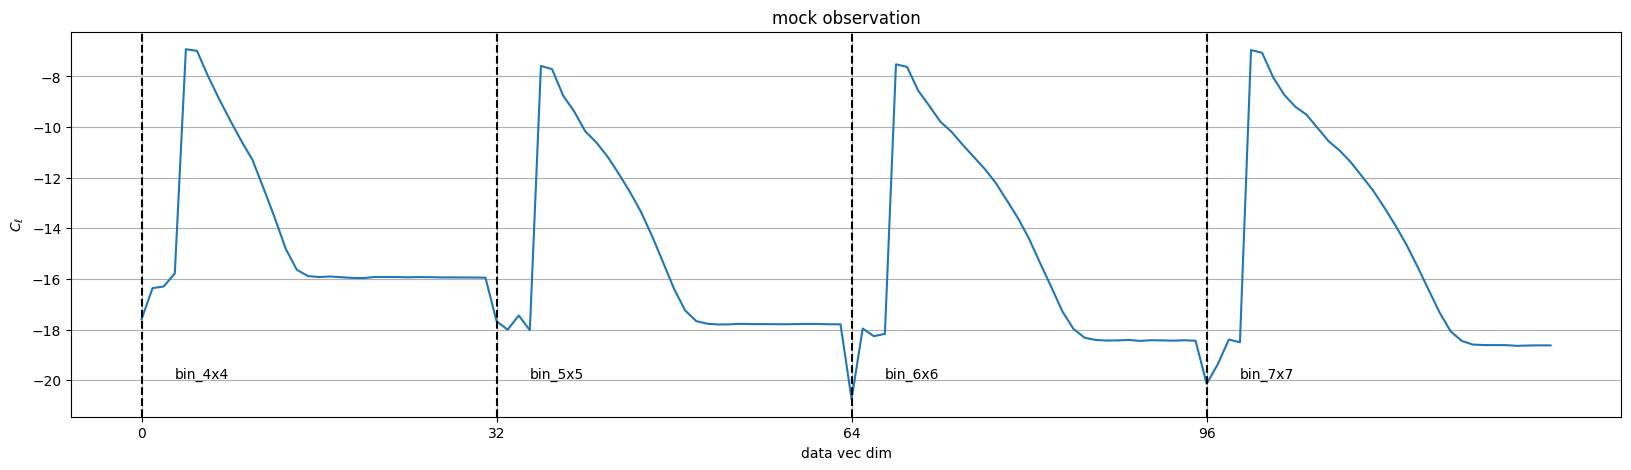

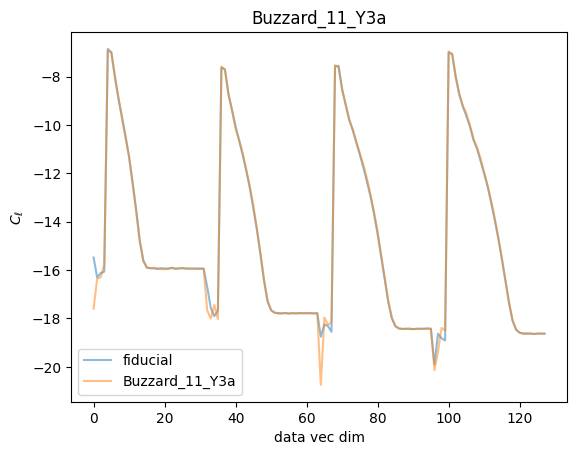

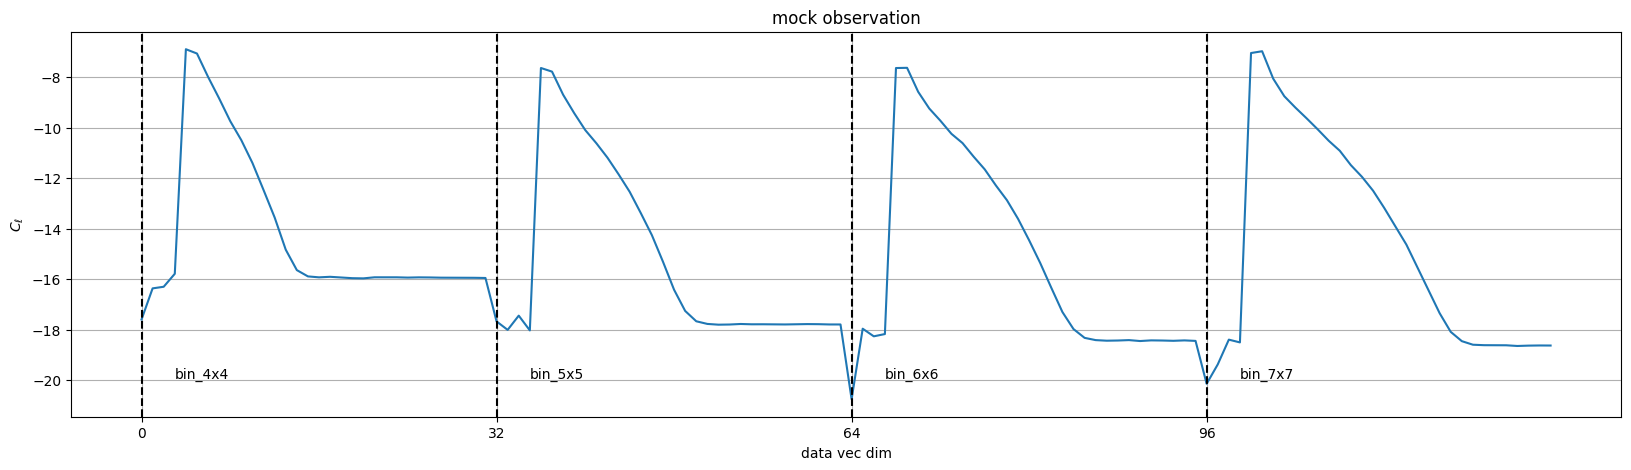

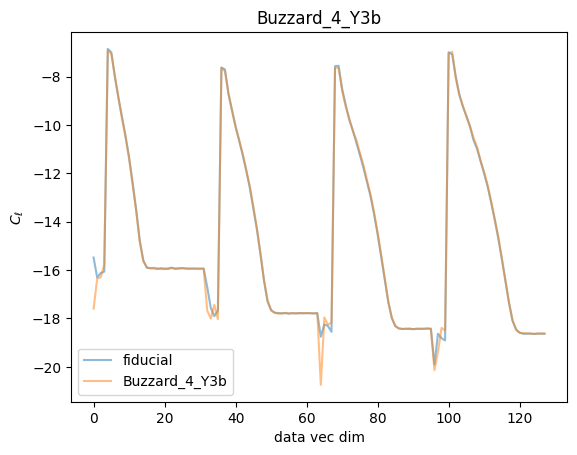

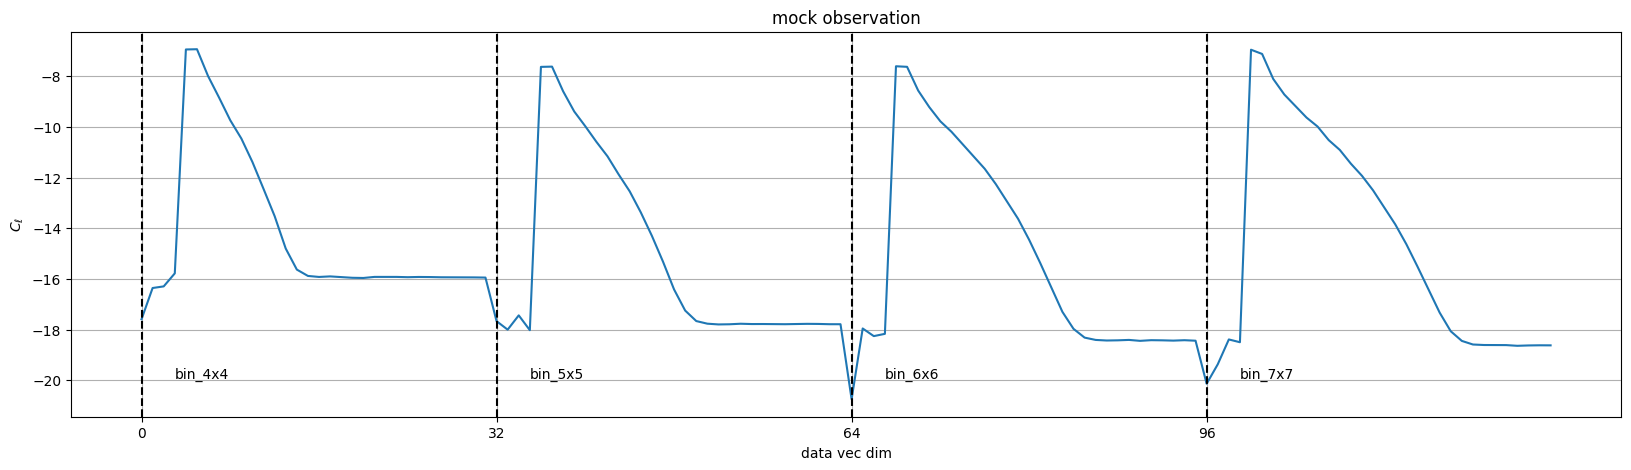

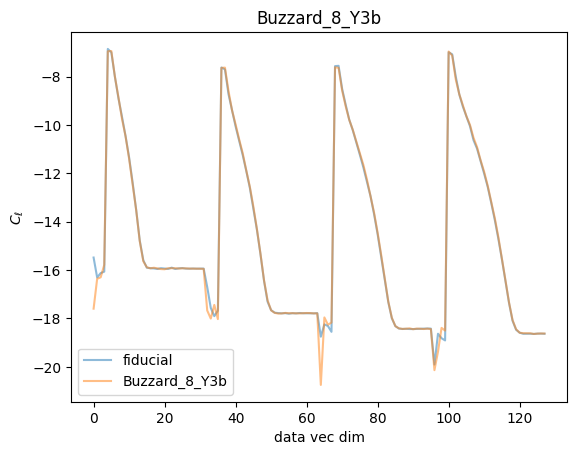

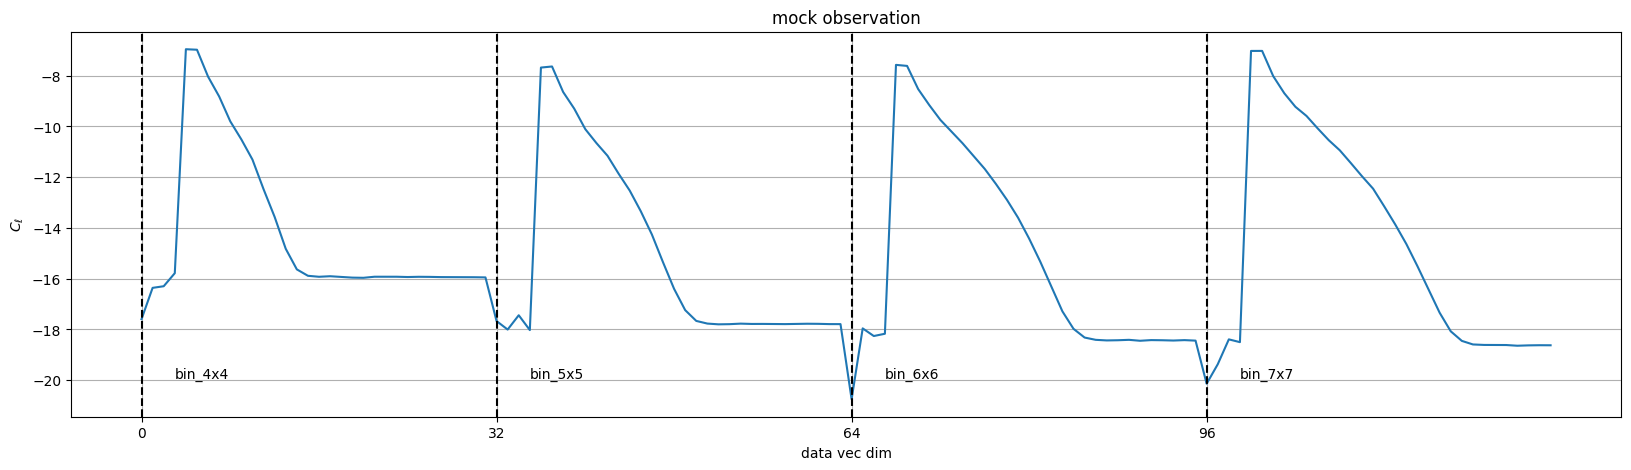

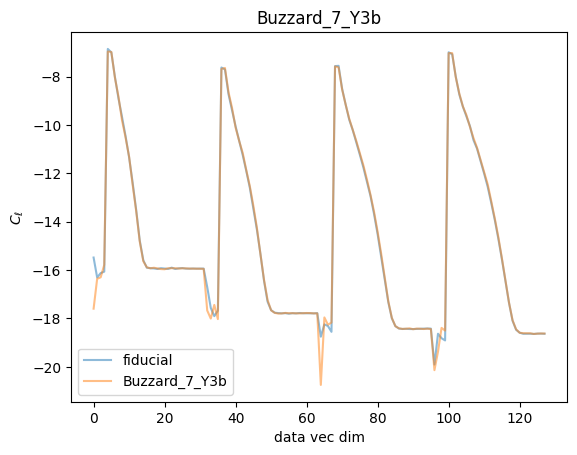

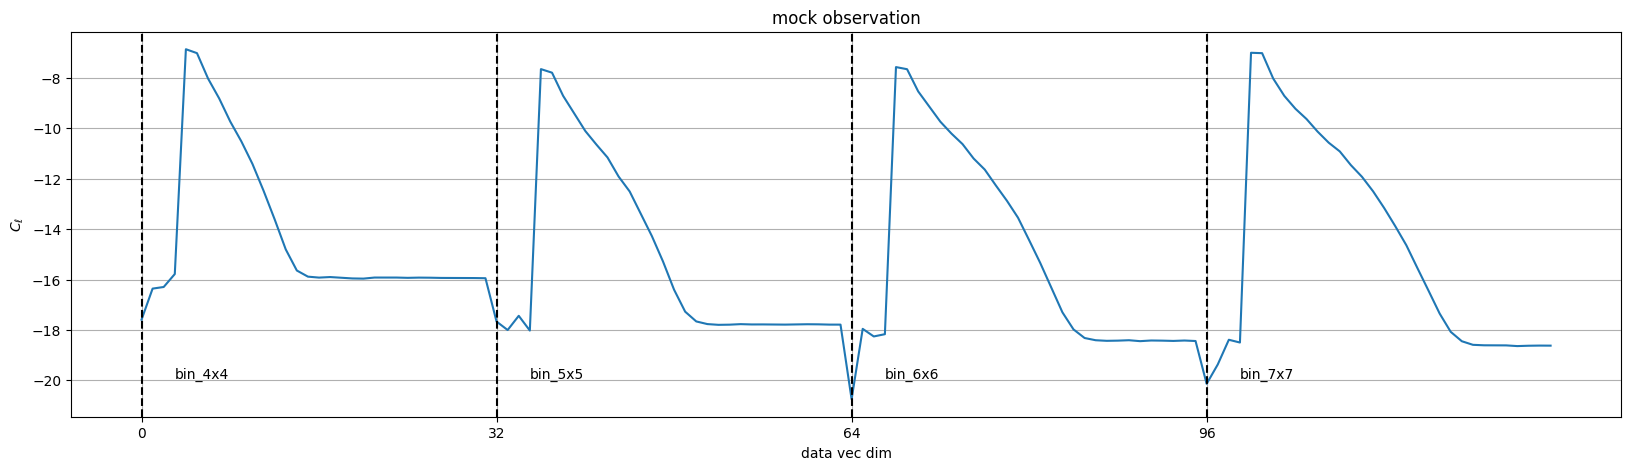

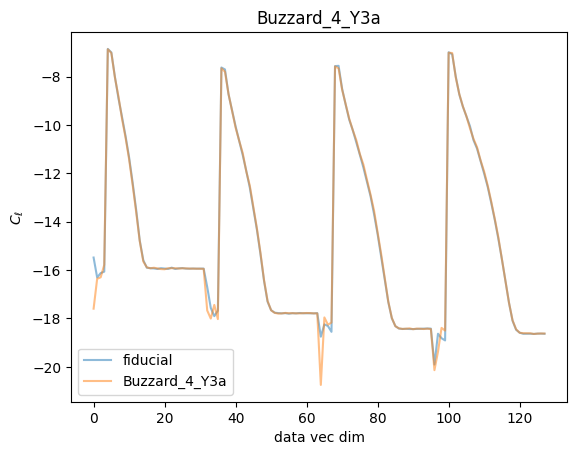

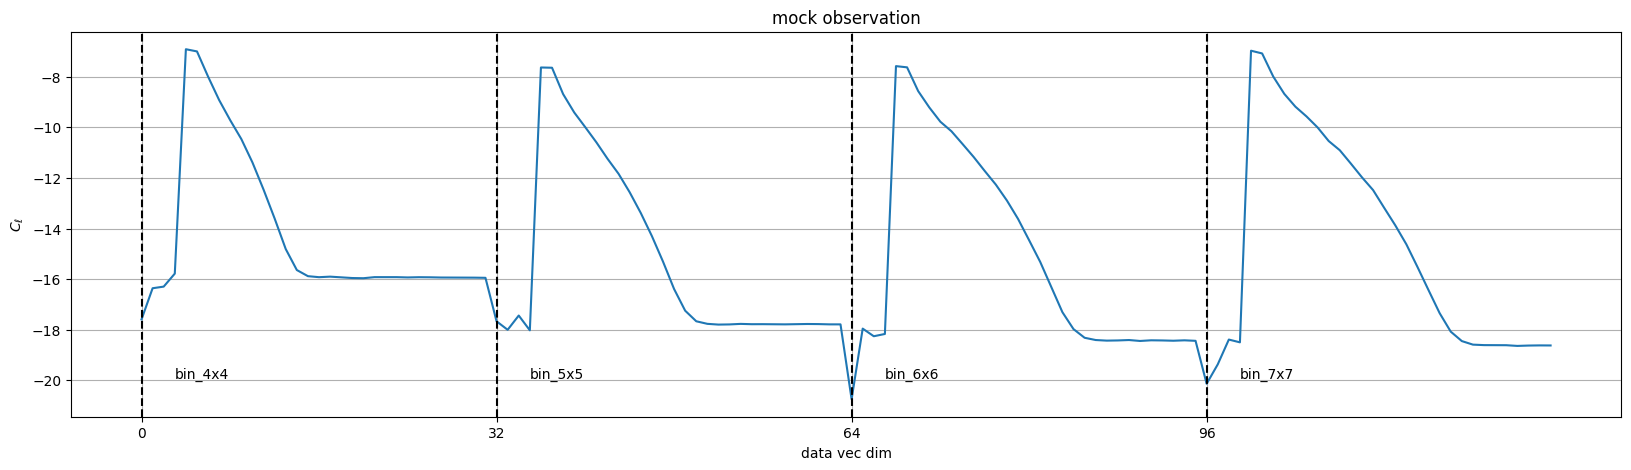

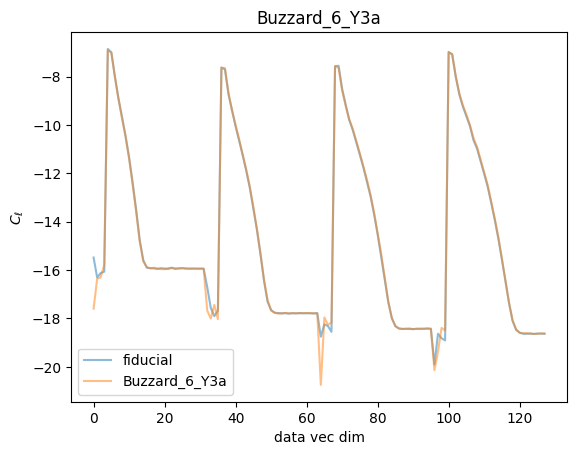

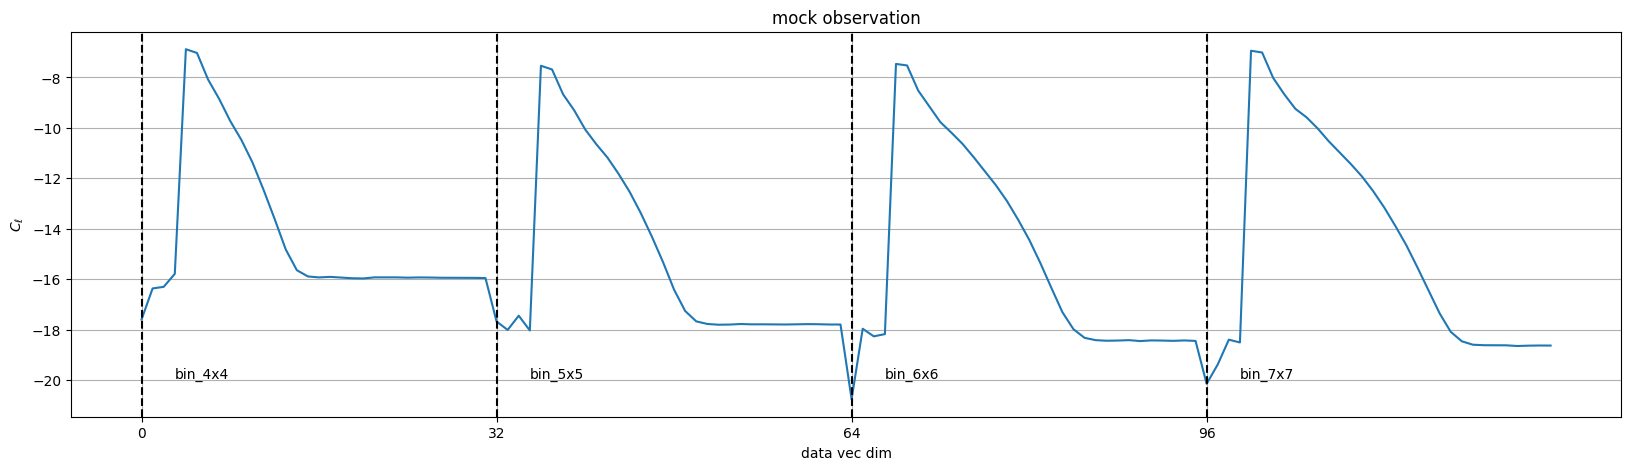

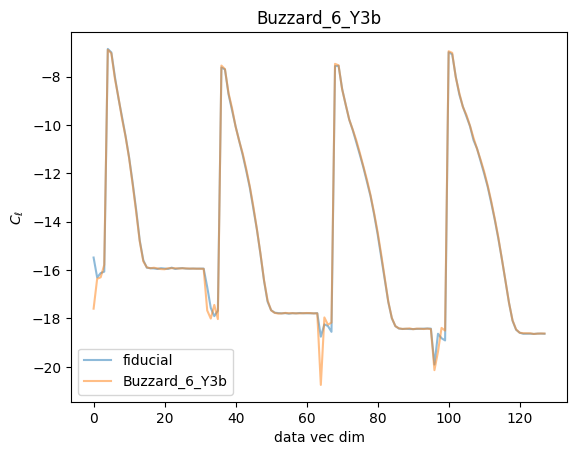

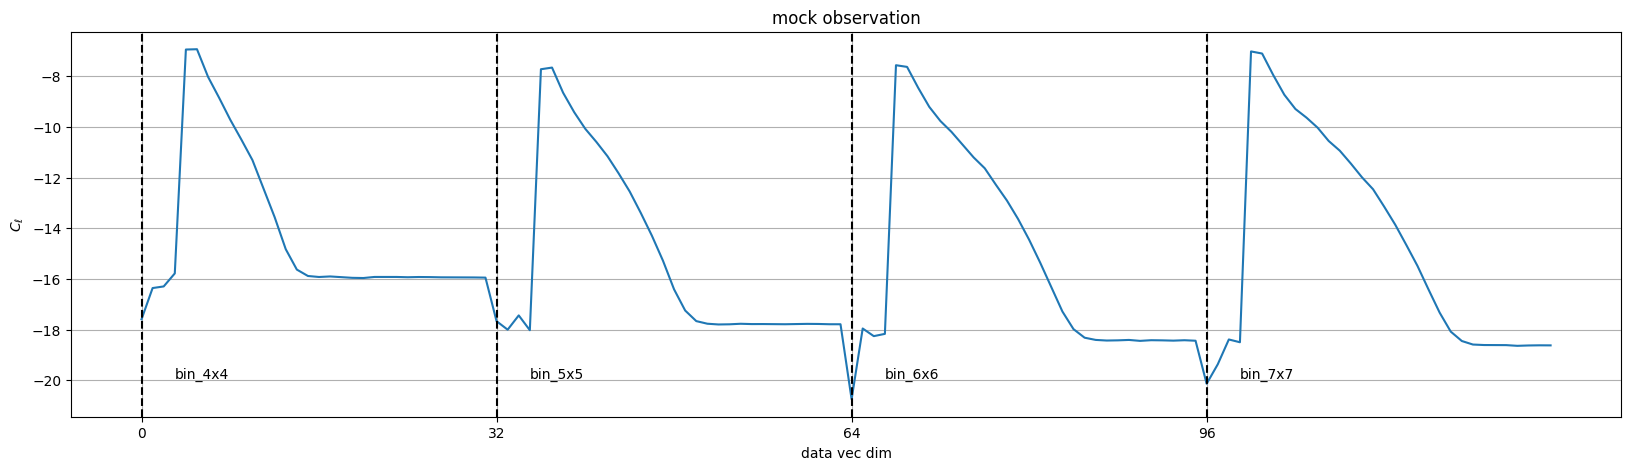

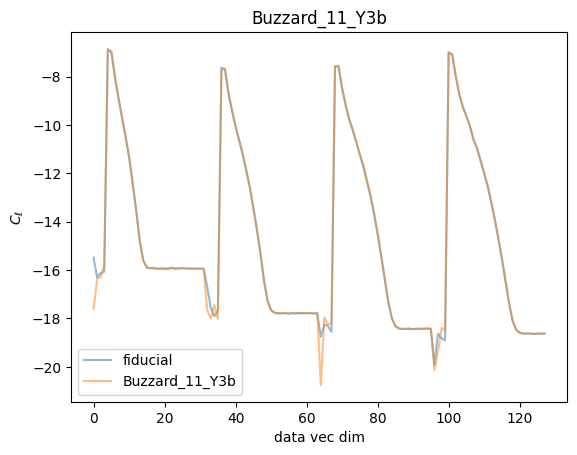

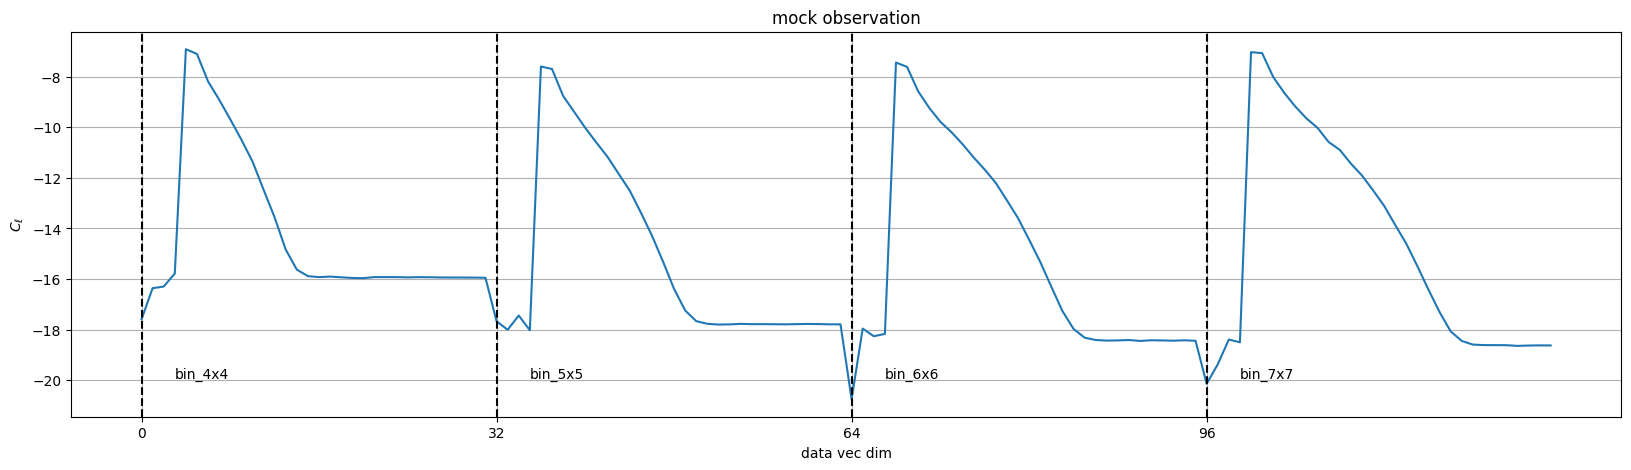

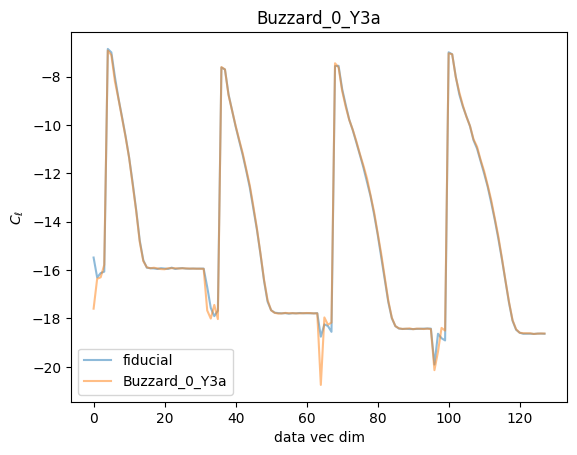

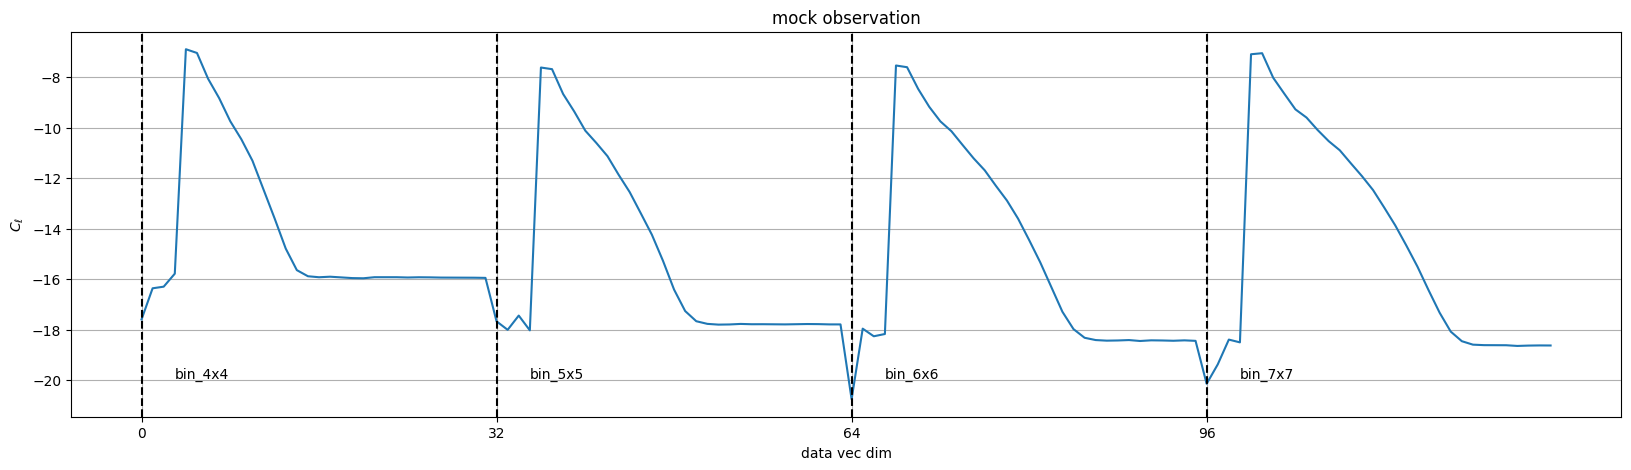

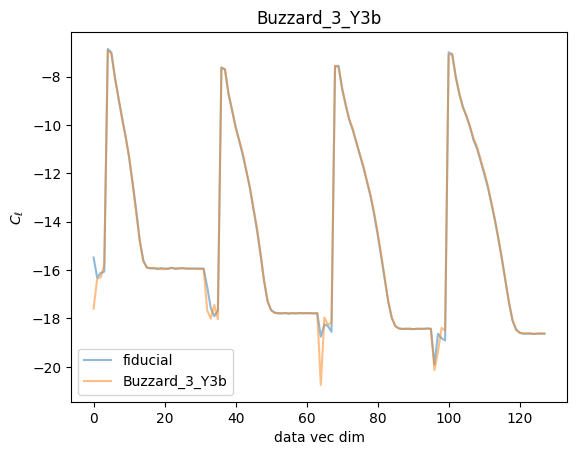

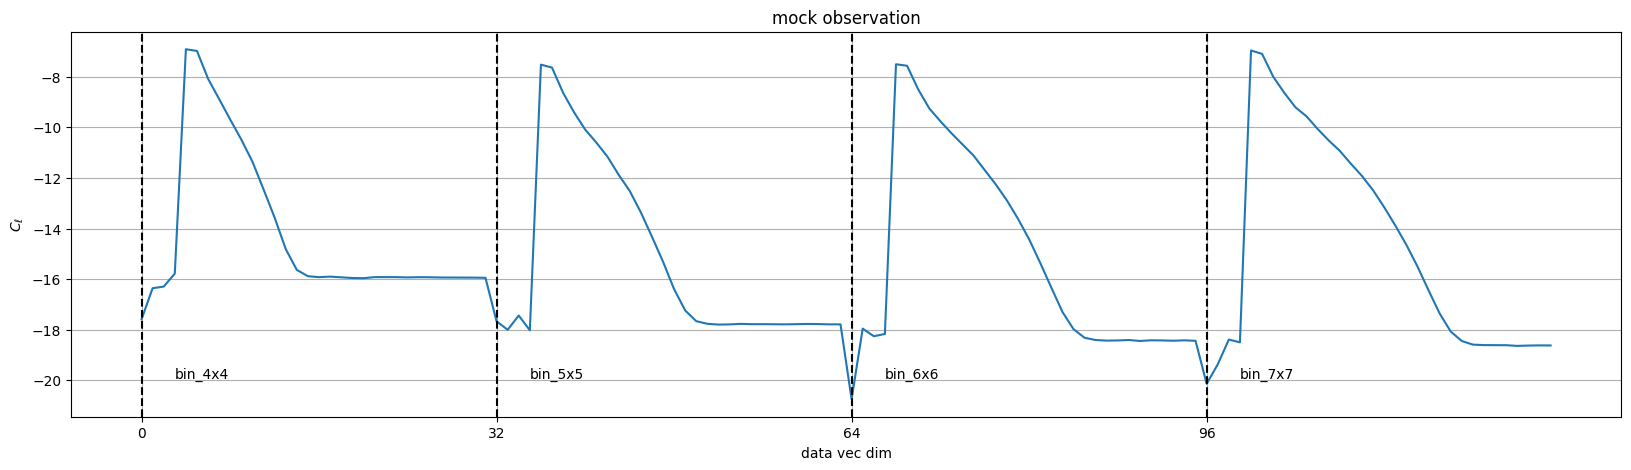

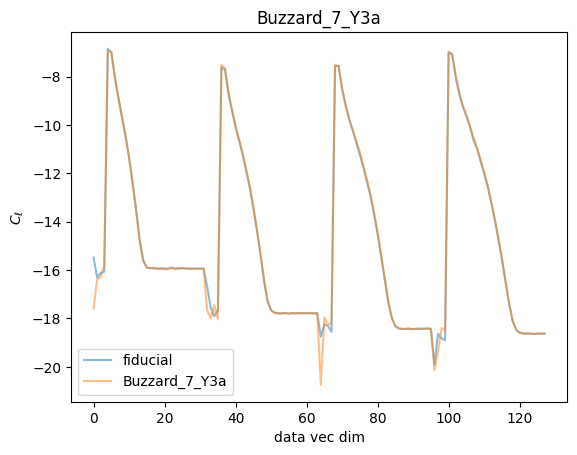

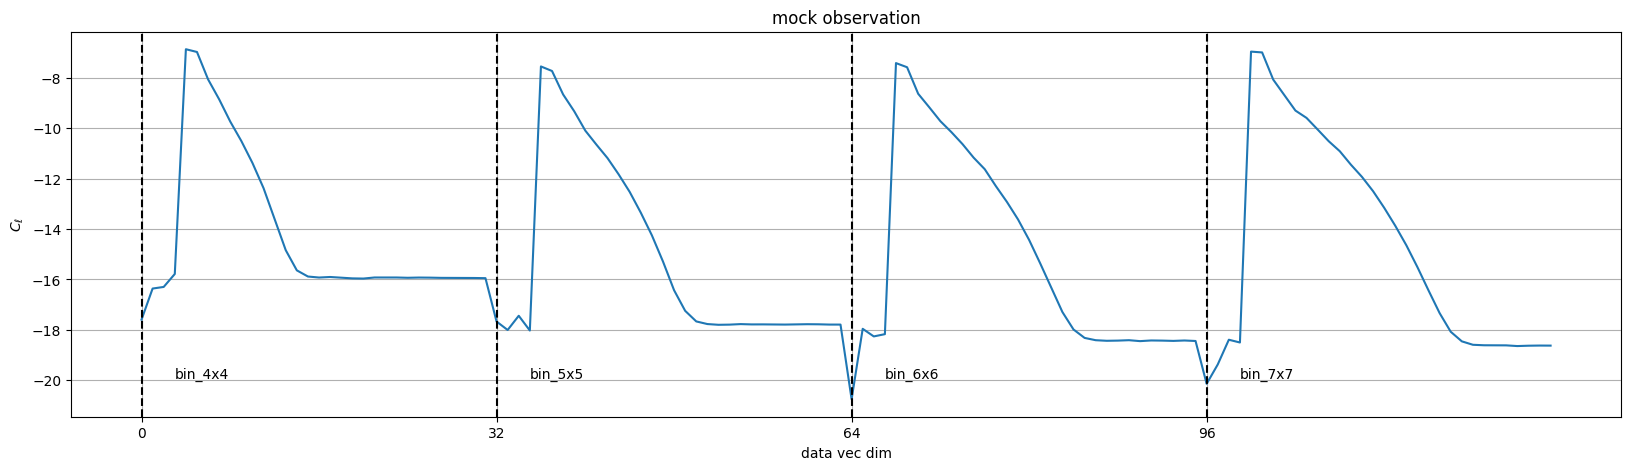

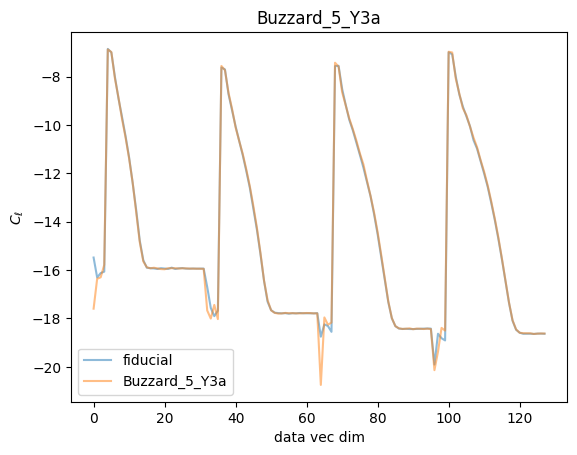

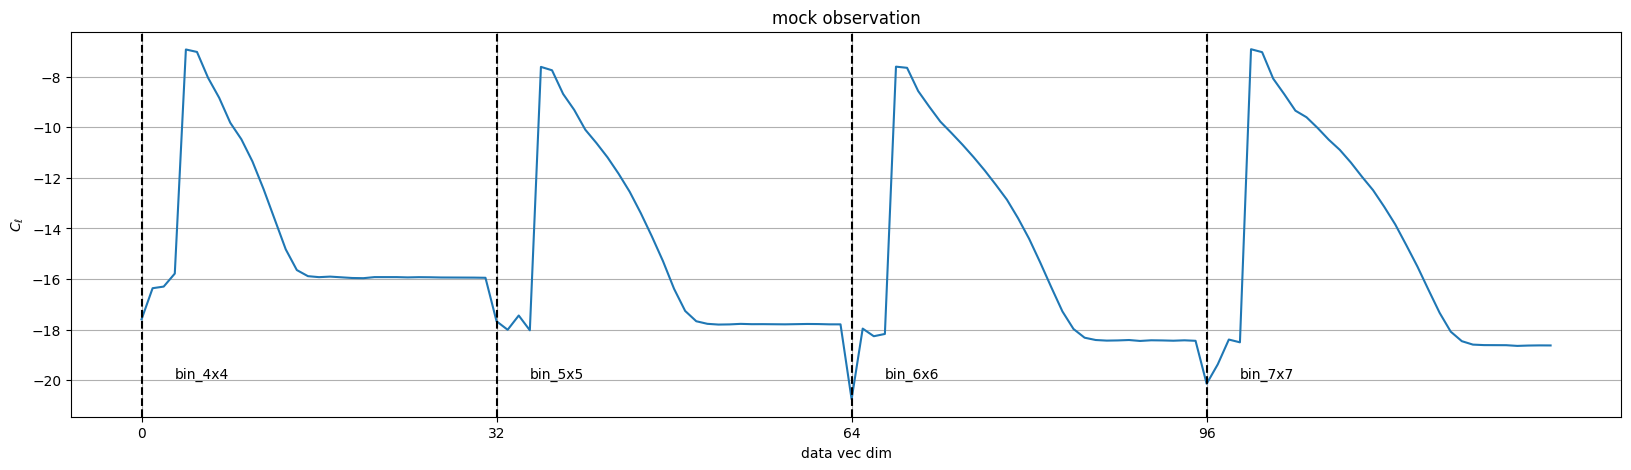

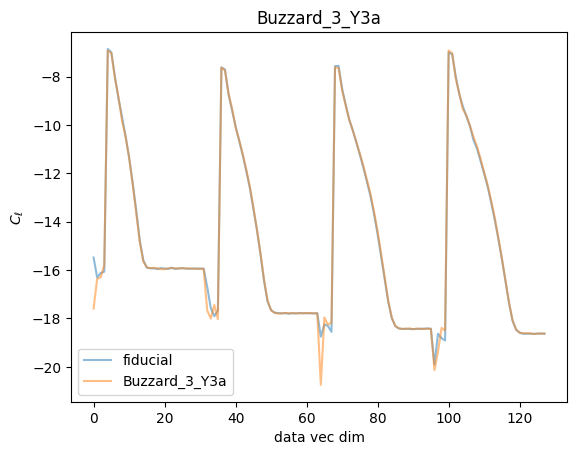

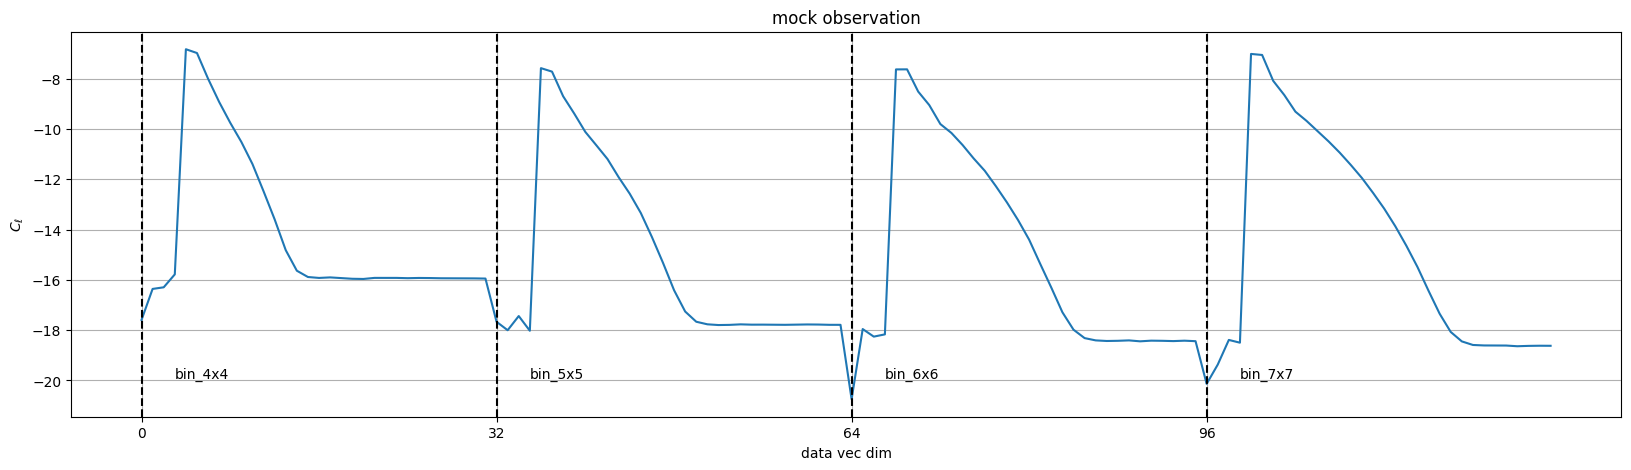

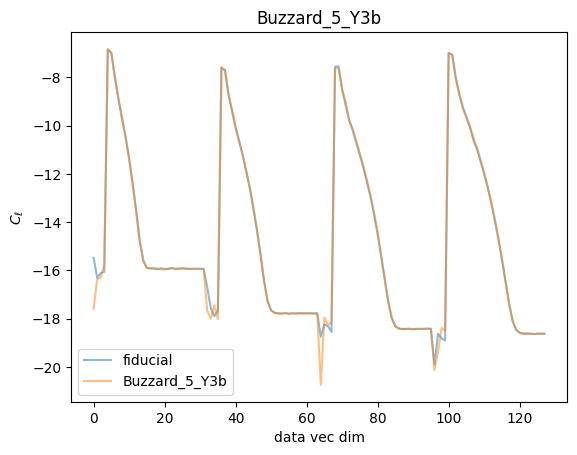

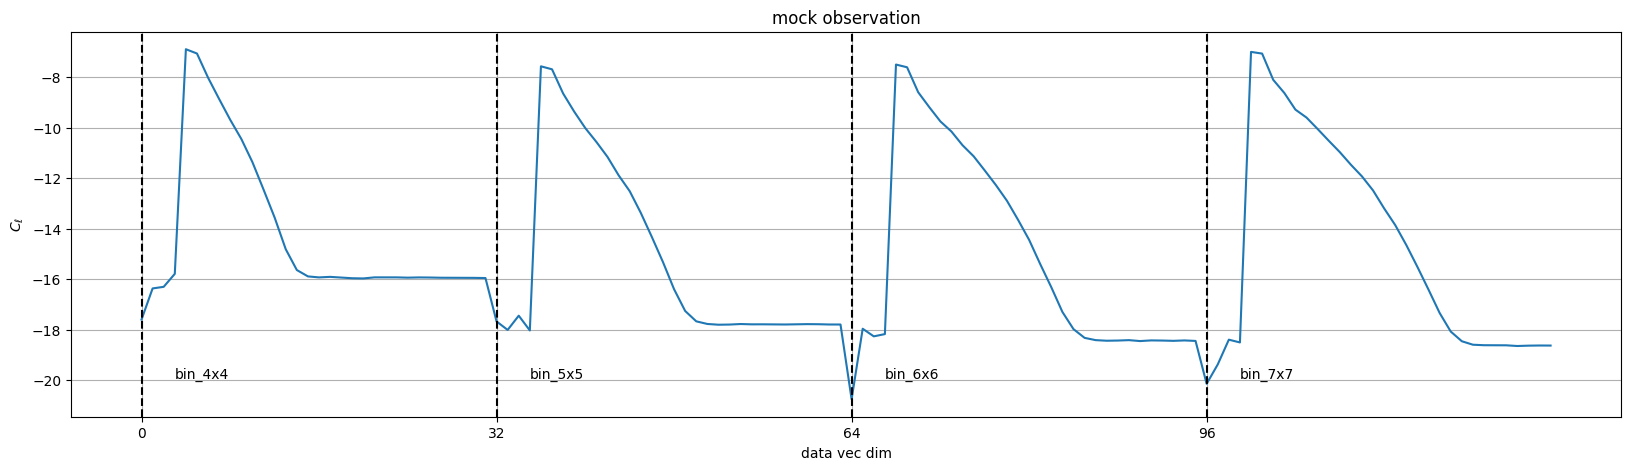

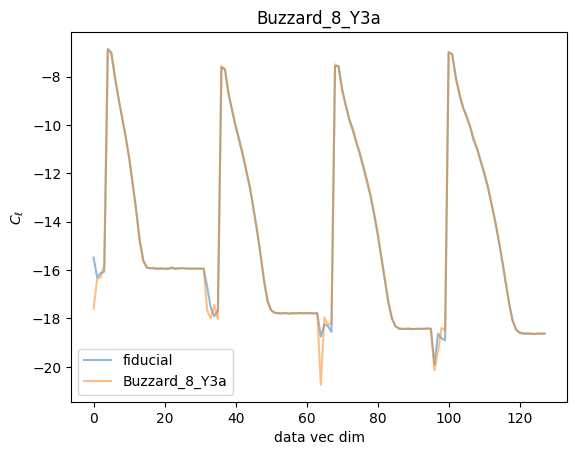

In [25]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# buzzard_flock_files = os.listdir(buzzard_flock_dir)

# with h5py.File(pred_file, "a") as f_out:
#     for buzzard_flock_file in buzzard_flock_files:
#         obs_file = os.path.join(buzzard_flock_dir, buzzard_flock_file)
#         obs_label = buzzard_flock_file[23:-3]
    
#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             msfm_conf=msfm_conf,
#             dlss_conf=dlss_conf,
#             base_dir=base_dir,
#             from_raw_cls=False,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=with_cross_z,
#             with_cross_probe=(with_lensing and with_clustering),
#             # bin_indices=[bin_index],
#             # additional preprocessing
#             apply_log=apply_log,
#             # standardize=standardize,
#             # scaler=scaler,
#             # pca_components=None,
#             # pca=pca,
#         )
        
#         fig, ax = plt.subplots()
#         ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
#         ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=0.5)
#         ax.legend(loc="best")
#         ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$", title=obs_label)

#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)


# old

In [26]:
# file_dict = input_output.load_human_summaries(
#     "/pscratch/sd/a/athomsen/v11desy3/v12/nonlinear",
#     "cls",
#     file_label=None,
#     return_raw_cls=False,
#     return_fiducial=False,
#     return_grid=True,
#     cls_from_maps=False,
# )

# cosmo = file_dict["grid/cosmo"]
# print(cosmo.shape)

In [27]:
# pca_components = 32

# grid_pca, scaler, pca = preprocessing.preprocess_human_summaries(
#     out_dict["grid/cls/test"], apply_log, standardize=False, pca_components=pca_components
# )
# # fidu_summs, _, _ = preprocess_human_summaries(
# #     fidu_summs, apply_log, standardize=standardize, pca_components=pca_components, scaler=scaler, pca=pca
# # )


In [28]:
# fidu_ex = out_dict["fidu/cls"][0,:]
# mock_ex = np.squeeze(obs_cl)

# fig, ax = plt.subplots()

# ax.plot(fidu_ex, label="fiducial", alpha=0.5)
# ax.plot(mock_ex, label="mock", alpha=0.5)

# ax.legend(loc="best")
# # ax.set(yscale="log")

### constant learning rate, gradient clipping

In [29]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-3)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": False}
# )

# train_model(model, do_validation=True)

In [30]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-4)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": False}
# )

# train_model(model, do_validation=True)
# cosine_schedule = False

In [31]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-3)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": True}
# )

# train_model(model, do_validation=True)
# cosine_schedule = False

### constant learning rate, no gradient clipping

In [32]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-3)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=None,
#     mutual_info_kwargs={"full_covariance": True}
# )

# train_model(model, do_validation=True)
# cosine_schedule = False

### cosine decay

In [33]:
# summary_net = get_cl_summary_network()

# lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
#     initial_learning_rate=1e-3, decay_steps=n_steps, alpha=0.0
# )
# optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": False}
# )

# train_model(model, do_validation=True)
# cosine_schedule = True

In [34]:
# summary_net = get_cl_summary_network()

# lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
#     initial_learning_rate=1e-3, decay_steps=n_steps, alpha=0.0
# )
# optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": True}
# )

# train_model(model, do_validation=True)
# cosine_schedule = True

# save results

In [35]:
# fidu_preds = model(out_dict["fidu/cls"])
# grid_preds = model(out_dict["grid/cls/test"])

# # pred_file = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},steps={n_steps}/preds.h5")
# pred_file = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_schedule},steps={n_steps}/preds.h5")
# # pred_file = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},steps={n_steps}/preds.h5")
# os.makedirs(os.path.dirname(pred_file), exist_ok=True)

# with h5py.File(pred_file, "w") as f:
#     f.create_dataset(name="grid/preds/test", data=grid_preds)
#     f.create_dataset(name="grid/cosmos/test", data=out_dict["grid/cosmos/test"])
#     f.create_dataset(name="fidu/preds", data=fidu_preds)
    
# print(f"Wrote to {pred_file}")

In [36]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# with h5py.File(pred_file, "a") as f_out:
#     for obs_label in mocks:
#         obs_file = f"/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_mock_observation_{obs_label}.h5"

#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             conf=msfm_conf,
#             from_raw_cls=True,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=True,
#             with_cross_probe=(with_lensing and with_clustering),
#             # CLs scale cuts
#             l_mins=l_mins,
#             l_maxs=l_maxs,
#             n_bins=n_bins,
#             # additional preprocessing
#             apply_log=apply_log,
#             standardize=standardize,
#             scaler=scaler,
#             pca_components=None,
#             pca=pca,
#         )
        
#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)
